# 🔬 DermaScan — Model Training Notebook

**Dataset:** HAM10000 — 10,015 dermoscopic images across 7 skin condition classes  
**Model:** EfficientNetB0 (ImageNet pre-trained) fine-tuned via transfer learning  
**Target:** ~85%+ validation accuracy

---
### ⚡ Quick start
1. Make sure **Runtime → Change runtime type → T4 GPU** is selected
2. Run all cells top to bottom (Runtime → Run all)
3. At the end, `dermascan.keras` will download automatically
4. Place that file in `backend/model/dermascan.keras`

## Section 1 — Install & Kaggle Setup

In [1]:
# Install dependencies
!pip install -q kaggle scikit-learn matplotlib seaborn
print('✅ Dependencies installed')

✅ Dependencies installed


In [2]:
# ── Paste your Kaggle credentials here ───────────────────
KAGGLE_USERNAME = "ethanharter"   # ← your Kaggle username
KAGGLE_KEY      = "KGAT_ceb37d023f07acfacca73288ff37791f"        # ← your API key

import os, json
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
creds_path = os.path.join(kaggle_dir, 'kaggle.json')
with open(creds_path, 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod(creds_path, 0o600)
print(f'✅ Kaggle configured for: {KAGGLE_USERNAME}')


✅ Kaggle configured for: ethanharter


## Section 2 — Download HAM10000 Dataset

In [5]:
# Download HAM10000 (~1.5 GB, takes ~2-4 min on Colab)
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 \
    --unzip -p /content/ham10000 -q
print('✅ Dataset downloaded')
!ls /content/ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
✅ Dataset downloaded
ham10000_images_part_1	HAM10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_1	HAM10000_metadata.csv	hmnist_8_8_L.csv
ham10000_images_part_2	hmnist_28_28_L.csv	hmnist_8_8_RGB.csv


## Section 3 — Data Exploration & Preprocessing

Total samples: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


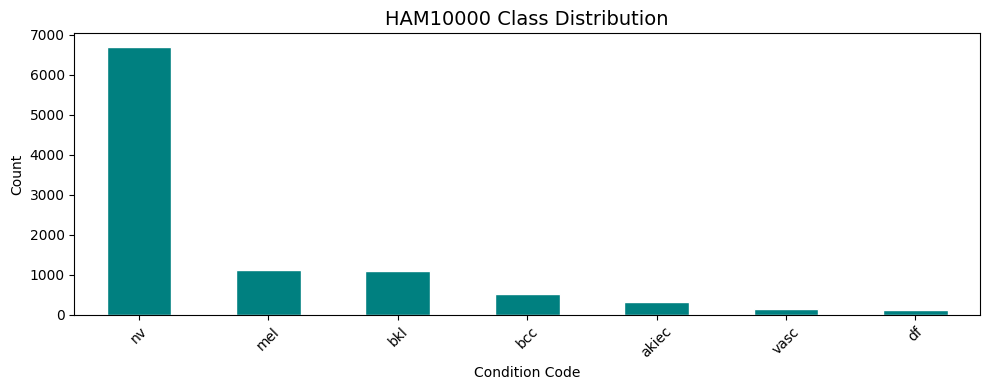

In [6]:
import pandas as pd
import numpy as np
import os, glob
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Load metadata CSV
meta_path = '/content/ham10000/HAM10000_metadata.csv'
df = pd.read_csv(meta_path)
print(f'Total samples: {len(df)}')
print(df['dx'].value_counts())

# Class distribution
plt.figure(figsize=(10, 4))
df['dx'].value_counts().plot(kind='bar', color='teal', edgecolor='white')
plt.title('HAM10000 Class Distribution', fontsize=14)
plt.xlabel('Condition Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Build image path lookup (images span two folders)
all_image_paths = glob.glob('/content/ham10000/**/*.jpg', recursive=True)
img_id_to_path = {os.path.splitext(os.path.basename(p))[0]: p for p in all_image_paths}
print(f'Total images found: {len(img_id_to_path)}')

# Map image_id → file path
df['path'] = df['image_id'].map(img_id_to_path)
df = df.dropna(subset=['path'])
print(f'Matched samples: {len(df)}')

Total images found: 10015
Matched samples: 10015


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# Stratified train/val split
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)
print(f'Train: {len(train_df)}  |  Val: {len(val_df)}')

# Compute class weights to handle imbalance
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].values
)
class_weights = dict(enumerate(weights))
print('Class weights:', {CLASS_NAMES[k]: round(v, 2) for k, v in class_weights.items()})

Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train: 8012  |  Val: 2003
Class weights: {'akiec': np.float64(4.37), 'bcc': np.float64(2.78), 'bkl': np.float64(1.3), 'df': np.float64(12.44), 'mel': np.float64(1.29), 'nv': np.float64(0.21), 'vasc': np.float64(10.04)}


## Section 4 — Build Data Generators

In [9]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = tf.image.rot90(img, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    return img, label

def preprocess_efficientnet(img, label):
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

def make_dataset(dataframe, augment_data=False):
    paths = dataframe['path'].values
    labels = dataframe['label'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.map(preprocess_efficientnet, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment_data=True)
val_ds   = make_dataset(val_df,   augment_data=False)
print('✅ Datasets ready')

✅ Datasets ready


## Section 5 — Build & Train EfficientNetB0

In [10]:
from tensorflow.keras import layers, Model

def build_model(num_classes=7):
    base = tf.keras.applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False  # Phase 1: frozen base

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs), base

model, base_model = build_model(NUM_CLASSES)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,330 (16.71 MB)

 Trainable params: 330,247 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [11]:
import os

os.makedirs('/content/checkpoints', exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/checkpoints/best_phase1.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

# ── Phase 1: Train head only (base frozen) ────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('\n🚀 Phase 1: Training classification head (5 epochs)...')
h1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks
)


🚀 Phase 1: Training classification head (5 epochs)...
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.3163 - loss: 1.8956
Epoch 1: val_accuracy improved from None to 0.58612, saving model to /content/checkpoints/best_phase1.keras

Epoch 1: finished saving model to /content/checkpoints/best_phase1.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 135s 385ms/step - accuracy: 0.3892 - loss: 1.5935 - val_accuracy: 0.5861 - val_loss: 1.1144 - learning_rate: 0.0010
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5091 - loss: 1.2540
Epoch 2: val_accuracy improved from 0.58612 to 0.61857, saving model to /content/checkpoints/best_phase1.keras

Epoch 2: finished saving model to /content/checkpoints/best_phase1.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 208ms/step - accuracy: 0.5417 - loss: 1.1976 - val_accuracy: 0.6186 - val_loss: 1.0375 - learning_rate: 0.0010
Epoch 3/5
249/251 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.5821 - loss: 1.0665
Epoch 3: val_accuracy improv

In [12]:
# ── Phase 2: Fine-tune top layers of base ─────────────────────────────────────
base_model.trainable = True

# Freeze all but the top 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/checkpoints/best_phase2.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

print('\n🚀 Phase 2: Fine-tuning top 30 layers (15 epochs)...')
h2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_p2
)


🚀 Phase 2: Fine-tuning top 30 layers (15 epochs)...
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.4577 - loss: 1.8389
Epoch 1: val_accuracy improved from None to 0.63155, saving model to /content/checkpoints/best_phase2.keras

Epoch 1: finished saving model to /content/checkpoints/best_phase2.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 118s 325ms/step - accuracy: 0.4688 - loss: 1.7478 - val_accuracy: 0.6316 - val_loss: 1.1586 - learning_rate: 1.0000e-05
Epoch 2/15
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.4820 - loss: 1.5746
Epoch 2: val_accuracy did not improve from 0.63155
251/251 ━━━━━━━━━━━━━━━━━━━━ 56s 201ms/step - accuracy: 0.4904 - loss: 1.5306 - val_accuracy: 0.5602 - val_loss: 1.3501 - learning_rate: 1.0000e-05
Epoch 3/15
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.4912 - loss: 1.4437
Epoch 3: val_accuracy did not improve from 0.63155
251/251 ━━━━━━━━━━━━━━━━━━━━ 85s 208ms/step - accuracy: 0.4974 - loss: 1.4568 - val_accuracy: 0.5676 -

## Section 6 — Evaluation


📊 Classification Report:
              precision    recall  f1-score   support

       akiec       0.29      0.46      0.36        65
         bcc       0.42      0.63      0.51       103
         bkl       0.38      0.44      0.41       220
          df       0.11      0.43      0.18        23
         mel       0.34      0.36      0.35       223
          nv       0.92      0.72      0.81      1341
        vasc       0.18      0.86      0.30        28

    accuracy                           0.63      2003
   macro avg       0.38      0.56      0.42      2003
weighted avg       0.73      0.63      0.67      2003



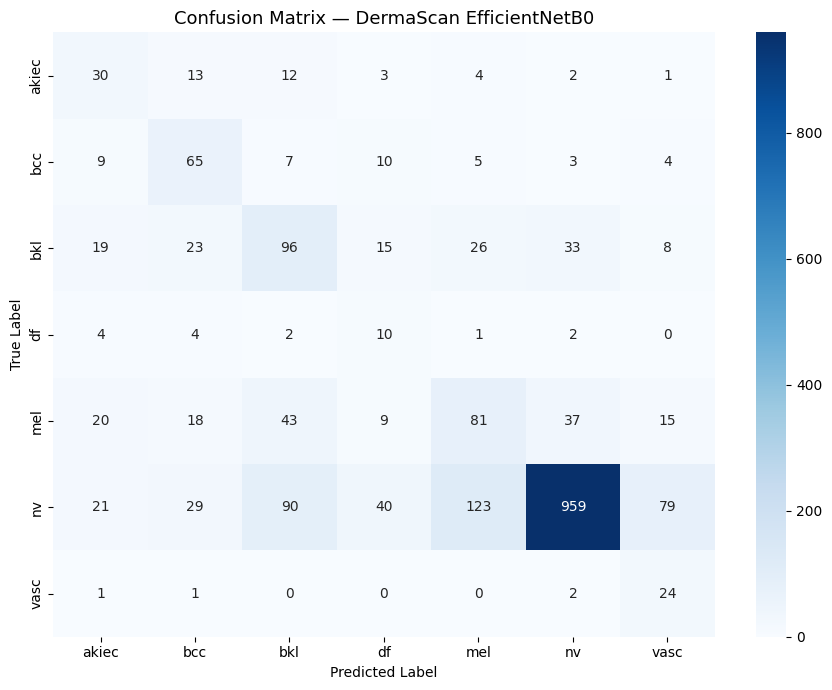

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Collect all val predictions
y_true, y_pred = [], []
for imgs, labels in val_ds:
    preds = model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print('\n📊 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — DermaScan EfficientNetB0', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Section 7 — Save & Download Model

In [14]:
# Save model in Keras format
model.save('/content/dermascan.keras')
print('✅ Model saved to /content/dermascan.keras')

# Verify file size
size_mb = os.path.getsize('/content/dermascan.keras') / (1024 * 1024)
print(f'📦 File size: {size_mb:.1f} MB')

✅ Model saved to /content/dermascan.keras
📦 File size: 31.5 MB


In [17]:
# Mount Google Drive and save model there
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/dermascan.keras', '/content/drive/MyDrive/dermascan.keras')
print('✅ Model saved to Google Drive → My Drive/dermascan.keras')

Mounted at /content/drive
✅ Model saved to Google Drive → My Drive/dermascan.keras


---
## ✅ Next Steps
1. Place `dermascan.keras` in `backend/model/`
2. Copy `backend/.env.example` → `backend/.env` and add your Gemini API key
3. Start the backend: `uvicorn backend.main:app --reload`
4. Open `frontend/index.html` in your browser

Get your free Gemini key at [aistudio.google.com](https://aistudio.google.com)